# Влияние базового порога пробоя

В этом ноутбуке исследуется влияние параметра `mean_breakdown_field` на развитие электрического пробоя.

Этот параметр задаёт базовый масштаб локального порога пробоя. При увеличении `mean_breakdown_field` материал становится труднее пробить.

Для каждого значения порога используются одинаковые наборы `disorder_seed` и `random_seed`, чтобы сравнение между режимами было корректным.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import SimulationConfig
from src.analysis_utils import (
    run_parameter_sweep,
    build_material_summary,
    build_bootstrap_summary,
)

In [2]:
base_config = SimulationConfig(
    nx=128,
    ny=128,
    eta=1.5,
    correlation_length=5.0,
    weibull_shape=5.0,
    max_growth_steps=5000,
)

In [3]:
threshold_values = [2.4, 2.7, 3.0, 3.3, 3.6]

disorder_seeds = range(20)
random_seeds = range(10)

total_runs = (
    len(threshold_values)
    * len(disorder_seeds)
    * len(random_seeds)
)

print("Total simulations:", total_runs)

Total simulations: 1000


## Основной sweep

Для каждого значения базового порога выполняются:

$$
20 \text{ реализаций материала}
\times
10 \text{ траекторий роста}
=
200 \text{ симуляций}.
$$

Всего выполняется 1000 запусков.

In [4]:
results_df = run_parameter_sweep(
    base_config=base_config,
    parameter_name="mean_breakdown_field",
    parameter_values=threshold_values,
    disorder_seeds=disorder_seeds,
    random_seeds=random_seeds,
)

In [5]:
print(results_df.shape)

print(
    results_df.groupby(
        "mean_breakdown_field"
    ).size()
)

results_df.to_csv(
    "threshold_results.csv",
    index=False,
)

(1000, 9)
mean_breakdown_field
2.4    200
2.7    200
3.0    200
3.3    200
3.6    200
dtype: int64


## Агрегация на уровне материала

Для каждого значения порога результаты сначала агрегируются по `disorder_seed`.

Одна строка `material_summary` соответствует одной реализации материала, усреднённой по десяти `random_seed`.

In [6]:
material_summary = build_material_summary(
    results_df,
    parameter_name="mean_breakdown_field",
)

material_summary.head()

,mean_breakdown_field,disorder_seed,n_started,n_breakdown,p_start,p_breakdown,mean_steps,mean_height,p_breakdown_given_start
0,2.4,0,10,10,1.0,1.0,392.5,1.0,1.0
1,2.4,1,10,10,1.0,1.0,380.6,1.0,1.0
2,2.4,2,10,10,1.0,1.0,408.5,1.0,1.0
3,2.4,3,10,10,1.0,1.0,416.8,1.0,1.0
4,2.4,4,10,10,1.0,1.0,388.2,1.0,1.0


In [7]:
stats = build_bootstrap_summary(
    material_summary,
    parameter_name="mean_breakdown_field",
    parameter_values=threshold_values,
    n_random=len(random_seeds),
)

stats

,p_start,p_start_low,p_start_high,p_breakdown,p_breakdown_low,p_breakdown_high,p_breakdown_given_start,conditional_low,conditional_high,mean_breakdown_field
0,1.00000,1.00,1.00,1.000000,1.000,1.000,1.000000,1.000000,1.0,2.4
1,0.64715,0.45,0.85,0.647150,0.450,0.850,1.000000,1.000000,1.0,2.7
2,0.59659,0.40,0.80,0.546310,0.300,0.750,0.915724,0.727273,1.0,3.0
3,0.35002,0.15,0.55,0.330308,0.150,0.530,0.943290,0.800000,1.0,3.3
4,0.30021,0.10,0.50,0.245987,0.095,0.445,0.820316,0.475000,1.0,3.6


In [16]:
empirical_summary = (
    results_df
    .groupby("mean_breakdown_field")
    .agg(
        p_start=("started", "mean"),
        p_breakdown=("breakdown", "mean"),
        n=("breakdown", "size"),
    )
)

conditional_summary = (
    results_df[results_df["started"]]
    .groupby("mean_breakdown_field")
    ["breakdown"]
    .mean()
    .rename("p_breakdown_given_start")
)

empirical_summary = empirical_summary.join(
    conditional_summary
)

empirical_summary

,p_start,p_breakdown,n,p_breakdown_given_start
mean_breakdown_field,,,,
2.4,1.00,1.000,200,1.000000
2.7,0.65,0.650,200,1.000000
3.0,0.60,0.550,200,0.916667
3.3,0.35,0.330,200,0.942857
3.6,0.30,0.245,200,0.816667


## Вероятность старта

Исследуем зависимость

$$
P(start \mid E_{bd}^{(0)}).
$$

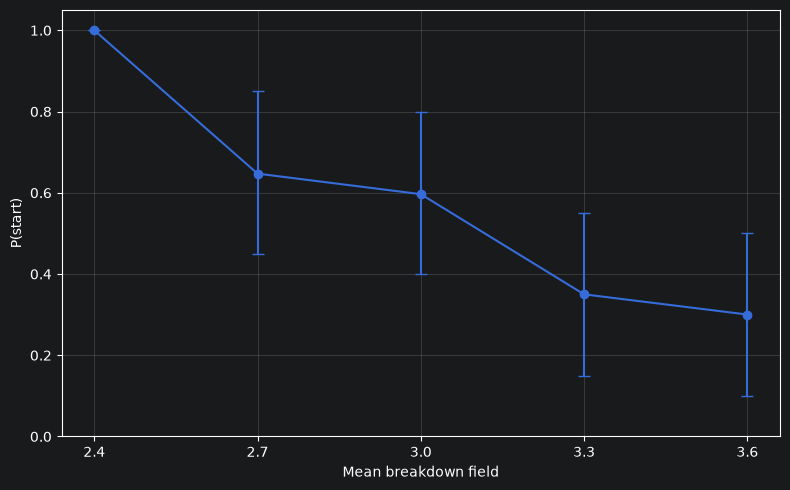

In [8]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    stats["p_start"] - stats["p_start_low"],
    stats["p_start_high"] - stats["p_start"],
])

plt.errorbar(
    stats["mean_breakdown_field"],
    stats["p_start"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("Mean breakdown field")
plt.ylabel("P(start)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Вывод

Вероятность старта канала существенно уменьшается при увеличении базового порога пробоя.

В исследованном диапазоне:

$$
P(start): 1.00 \rightarrow 0.30
$$

при изменении

$$
E_{bd}^{(0)}: 2.4 \rightarrow 3.6.
$$

Это соответствует физическому смыслу параметра: рост может начаться только тогда, когда хотя бы на одной клетке фронта выполняется условие

$$
\frac{E_i}{S_i} > E_{bd}^{(0)}.
$$

Поэтому увеличение порога уменьшает число реализаций материала, в которых существует хотя бы одна активная клетка.

Наиболее резкое изменение наблюдается в области примерно

$$
E_{bd}^{(0)} \sim 2.7 - 3.3,
$$

что указывает на переходный режим модели.

## Вероятность полного пробоя

Исследуем переходную кривую

$$
P(breakdown \mid E_{bd}^{(0)}).
$$

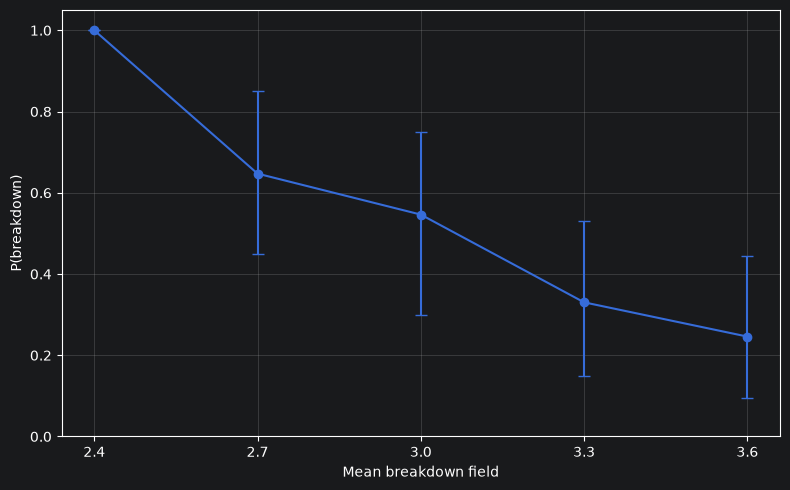

In [9]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    stats["p_breakdown"] - stats["p_breakdown_low"],
    stats["p_breakdown_high"] - stats["p_breakdown"],
])

plt.errorbar(
    stats["mean_breakdown_field"],
    stats["p_breakdown"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("Mean breakdown field")
plt.ylabel("P(breakdown)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Вывод

Общая вероятность полного пробоя также монотонно уменьшается с ростом порога:

$$
P(breakdown): 1.00 \rightarrow 0.245.
$$

В частности,

$$
P(breakdown) \approx 0.55
$$

при

$$
E_{bd}^{(0)}=3.0.
$$

Таким образом, значение около $E_{bd}^{(0)}=3.0$ находится близко к центру переходной области и особенно информативно для статистического анализа и будущего ML-датасета.

In [18]:
pivot_breakdown = material_summary.pivot(
    index="disorder_seed",
    columns="mean_breakdown_field",
    values="p_breakdown",
)

stat, p_value = friedmanchisquare(
    *[
        pivot_breakdown[value].values
        for value in threshold_values
    ]
)

kendall_w = (
    stat
    / (
        len(pivot_breakdown)
        * (len(threshold_values) - 1)
    )
)

print("Friedman statistic:", stat)
print("p-value:", p_value)
print("Kendall W:", kendall_w)

Friedman statistic: 40.73469387755098
p-value: 3.050171193122526e-08
Kendall W: 0.5091836734693873


In [19]:
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

pairwise_breakdown = []

for value1, value2 in combinations(
    threshold_values,
    2,
):
    x = pivot_breakdown[value1].values
    y = pivot_breakdown[value2].values

    if np.allclose(x, y):
        stat = 0.0
        p_value = 1.0
    else:
        stat, p_value = wilcoxon(x, y)

    pairwise_breakdown.append(
        {
            "threshold1": value1,
            "threshold2": value2,
            "mean_diff": np.mean(x - y),
            "p_value": p_value,
        }
    )

pairwise_breakdown = pd.DataFrame(
    pairwise_breakdown
)

pairwise_breakdown["p_adjusted"] = multipletests(
    pairwise_breakdown["p_value"],
    method="holm",
)[1]

pairwise_breakdown["significant"] = (
    pairwise_breakdown["p_adjusted"] < 0.05
)

pairwise_breakdown

,threshold1,threshold2,mean_diff,p_value,p_adjusted,significant
0,2.4,2.7,0.350,0.008151,0.048906,True
1,2.4,3.0,0.450,0.002700,0.021598,True
2,2.4,3.3,0.670,0.000275,0.002473,True
3,2.4,3.6,0.755,0.000096,0.000962,True
4,2.7,3.0,0.100,0.157299,0.217619,False
5,2.7,3.3,0.320,0.011412,0.057060,False
6,2.7,3.6,0.405,0.003892,0.027247,True
7,3.0,3.3,0.220,0.033895,0.101685,False
8,3.0,3.6,0.305,0.011412,0.057060,False
9,3.3,3.6,0.085,0.108809,0.217619,False


## Вероятность полного пробоя после старта

Отдельно рассматривается

$$
P(breakdown \mid start, E_{bd}^{(0)}).
$$

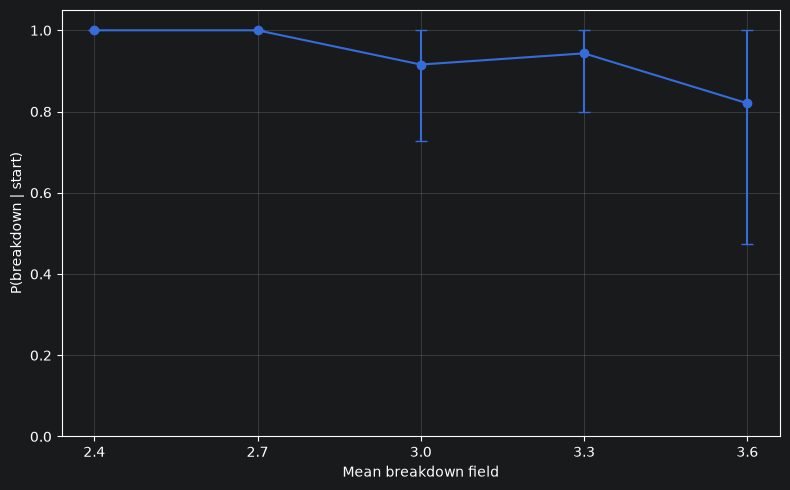

In [10]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    stats["p_breakdown_given_start"] - stats["conditional_low"],
    stats["conditional_high"] - stats["p_breakdown_given_start"],
])

plt.errorbar(
    stats["mean_breakdown_field"],
    stats["p_breakdown_given_start"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("Mean breakdown field")
plt.ylabel("P(breakdown | start)")
plt.xticks(threshold_values)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [20]:
conditional_counts = (
    material_summary
    .groupby("mean_breakdown_field")
    ["p_breakdown_given_start"]
    .count()
)

conditional_counts

mean_breakdown_field
2.4    20
2.7    13
3.0    12
3.3     7
3.6     6
Name: p_breakdown_given_start, dtype: int64

### Вывод по распространению после старта

Условная вероятность полного пробоя после возникновения канала остаётся высокой во всём рассматриваемом диапазоне:

$$
P(breakdown \mid start)
\approx
1.00,\ 1.00,\ 0.92,\ 0.94,\ 0.82.
$$

Это показывает, что основное влияние увеличения $E_{bd}^{(0)}$ проявляется на стадии **инициации пробоя**.

Если канал уже смог возникнуть, то в большинстве случаев он достигает противоположного электрода.

При больших значениях порога число материалов, в которых рост вообще начинается, становится небольшим. Например, для $E_{bd}^{(0)}=3.6$ условная вероятность оценивается только по 6 независимым реализациям материала.

Поэтому формальный repeated-measures тест для
$P(breakdown \mid start)$
здесь использовать не следует: complete-case выборка слишком мала и дополнительно смещена в сторону материалов, способных стартовать при всех порогах.

Для этого показателя используются cluster-bootstrap confidence intervals и описательная интерпретация.

## Дополнительные характеристики роста

Также рассматриваются среднее число шагов и относительная высота канала.

In [21]:
started_df = results_df[
    results_df["started"]
].copy()

growth_summary = (
    started_df
    .groupby("mean_breakdown_field")
    .agg(
        n_started=("steps", "size"),
        mean_steps=("steps", "mean"),
        median_steps=("steps", "median"),
        std_steps=("steps", "std"),
        mean_height=("height_fraction", "mean"),
        median_height=("height_fraction", "median"),
    )
)

growth_summary

,n_started,mean_steps,median_steps,std_steps,mean_height,median_height
mean_breakdown_field,,,,,,
2.4,200,394.055000,392.0,62.074295,1.000000,1.0
2.7,130,375.246154,377.0,60.280361,1.000000,1.0
3.0,120,317.275000,346.0,106.649978,0.927165,1.0
3.3,70,315.042857,320.5,92.759536,0.950056,1.0
3.6,60,248.766667,287.5,125.501890,0.837533,1.0


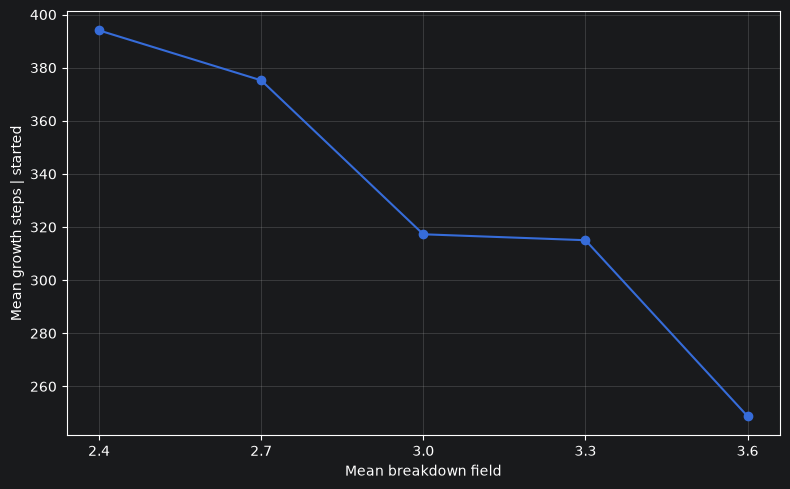

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    growth_summary.index,
    growth_summary["mean_steps"],
    marker="o",
)

plt.xlabel("Mean breakdown field")
plt.ylabel("Mean growth steps | started")
plt.xticks(threshold_values)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Вывод по динамике стартовавших каналов

Среди траекторий, в которых рост всё же начался, среднее число шагов также уменьшается при увеличении порога:

$$
394 \rightarrow 249.
$$

Однако этот результат необходимо интерпретировать осторожно.

При больших значениях $E_{bd}^{(0)}$ стартуют уже не случайные материалы, а преимущественно наиболее благоприятные реализации disorder. Следовательно, состав условной выборки

$$
\{trajectory \mid start\}
$$

изменяется вместе с порогом.

Поэтому уменьшение числа шагов нельзя интерпретировать как чистый причинный эффект порога на скорость роста. Оно частично связано с selection effect: при больших порогах остаются только материалы с особенно благоприятными путями распространения.

In [23]:
status_counts = pd.crosstab(
    results_df["mean_breakdown_field"],
    results_df["status"],
)

status_counts

status,arrested,breakdown,no_start
mean_breakdown_field,,,
2.4,0,200,0
2.7,0,130,70
3.0,10,110,80
3.3,4,66,130
3.6,11,49,140


### Режимы системы

Распределение итоговых состояний хорошо показывает переход между режимами.

При

$$
E_{bd}^{(0)}=2.4
$$

все 200 симуляций заканчиваются полным пробоем.

При увеличении порога постепенно возрастает доля `no_start`, а доля `breakdown` уменьшается.

Состояние `arrested` появляется преимущественно в переходной области, когда локального поля достаточно для возникновения канала, но недостаточно для устойчивого распространения через весь материал.

Таким образом, модель демонстрирует три физически различимых режима:

$$
no\ start
\rightarrow
arrested
\rightarrow
breakdown.
$$

## Статистическая проверка влияния порога на вероятность старта

Для всех значений порога используются одинаковые `disorder_seed`, поэтому применяем критерий Фридмана для связанного дизайна.

In [17]:
from scipy.stats import friedmanchisquare

pivot_start = material_summary.pivot(
    index="disorder_seed",
    columns="mean_breakdown_field",
    values="p_start",
)

stat, p_value = friedmanchisquare(
    *[
        pivot_start[value].values
        for value in threshold_values
    ]
)

kendall_w = (
    stat
    / (
        len(pivot_start)
        * (len(threshold_values) - 1)
    )
)

print("Friedman statistic:", stat)
print("p-value:", p_value)
print("Kendall W:", kendall_w)

Friedman statistic: 36.82352941176478
p-value: 1.9585614613510528e-07
Kendall W: 0.46029411764705974


### Статистическая проверка влияния порога на старт

Критерий Фридмана показал статистически значимое влияние базового порога пробоя на вероятность старта:

$$
\chi_F^2 \approx 36.82,
$$

$$
p \approx 1.96 \times 10^{-7}.
$$

Размер эффекта по Kendall's W составляет

$$
W \approx 0.46.
$$

Следовательно, изменение `mean_breakdown_field` оказывает выраженное влияние на вероятность возникновения канала.

In [14]:
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

pairwise_results = []

for value1, value2 in combinations(threshold_values, 2):
    x = pivot_start[value1].values
    y = pivot_start[value2].values

    if np.allclose(x, y):
        stat = 0.0
        p_value = 1.0
    else:
        stat, p_value = wilcoxon(x, y)

    pairwise_results.append(
        {
            "threshold1": value1,
            "threshold2": value2,
            "mean_diff": np.mean(x - y),
            "p_value": p_value,
        }
    )

pairwise_df = pd.DataFrame(pairwise_results)

pairwise_df["p_adjusted"] = multipletests(
    pairwise_df["p_value"],
    method="holm",
)[1]

pairwise_df["significant"] = (
    pairwise_df["p_adjusted"] < 0.05
)

pairwise_df

,threshold1,threshold2,mean_diff,p_value,p_adjusted,significant
0,2.4,2.7,0.35,0.008151,0.057057,False
1,2.4,3.0,0.40,0.004678,0.037422,True
2,2.4,3.3,0.65,0.000311,0.002803,True
3,2.4,3.6,0.70,0.000183,0.001828,True
4,2.7,3.0,0.05,0.317311,0.634621,False
5,2.7,3.3,0.30,0.014306,0.071529,False
6,2.7,3.6,0.35,0.008151,0.057057,False
7,3.0,3.3,0.25,0.025347,0.076042,False
8,3.0,3.6,0.30,0.014306,0.071529,False
9,3.3,3.6,0.05,0.317311,0.634621,False


### Post-hoc анализ старта

После поправки Холма наиболее уверенно отличаются режимы с низким порогом
$E_{bd}^{(0)}=2.4$ от более высоких порогов.

При этом различия между соседними значениями порога часто не достигают статистической значимости после поправки на множественные сравнения.

Таким образом, общий эффект порога выражен хорошо, но для точной локализации границ переходной области требуется более плотный sweep или большее число независимых реализаций материала.

## Оценка переходной области

Для будущего датасета особенно важны значения порога, где вероятность полного пробоя находится около 50%, а не около 0 или 1.

In [15]:
transition_table = stats[
    [
        "mean_breakdown_field",
        "p_breakdown",
        "p_breakdown_low",
        "p_breakdown_high",
    ]
].copy()

transition_table["distance_to_05"] = (
    transition_table["p_breakdown"] - 0.5
).abs()

transition_table.sort_values(
    "distance_to_05"
)

,mean_breakdown_field,p_breakdown,p_breakdown_low,p_breakdown_high,distance_to_05
2,3.0,0.546310,0.300,0.750,0.046310
1,2.7,0.647150,0.450,0.850,0.147150
3,3.3,0.330308,0.150,0.530,0.169692
4,3.6,0.245987,0.095,0.445,0.254013
0,2.4,1.000000,1.000,1.000,0.500000


## Итоговый вывод

Параметр `mean_breakdown_field` является одним из основных управляющих параметров модели электрического пробоя.

При увеличении

$$
E_{bd}^{(0)}: 2.4 \rightarrow 3.6
$$

вероятность старта уменьшается

$$
1.00 \rightarrow 0.30,
$$

а вероятность полного пробоя

$$
1.00 \rightarrow 0.245.
$$

Критерий Фридмана подтверждает статистически значимое влияние порога как на вероятность старта,

$$
p \approx 1.96\times10^{-7},
\qquad
W \approx 0.46,
$$

так и на общую вероятность полного пробоя,

$$
p \approx 3.05\times10^{-8},
\qquad
W \approx 0.51.
$$

При этом

$$
P(breakdown \mid start)
$$

остаётся сравнительно высокой во всём исследованном диапазоне.

Это показывает, что основной механизм влияния `mean_breakdown_field` связан с **инициацией канала**: повышение порога прежде всего уменьшает вероятность возникновения активной области на начальном фронте.

Значение

$$
E_{bd}^{(0)} \approx 3.0
$$

находится близко к центру переходной области:

$$
P(breakdown)\approx0.55.
$$

Поэтому диапазон приблизительно

$$
E_{bd}^{(0)}\in[2.7,3.6]
$$

является наиболее информативным для последующего joint sweep и генерации ML-датасета.

В отличие от крайних режимов, здесь присутствуют одновременно `no_start`, `arrested` и `breakdown`, что позволяет исследовать границу фазовых режимов и обучать модели на нетривиальном распределении исходов.